# EEG Classification: AD vs CN — XGBoost with LOO-CV

**Pipeline:**
1. Subject-level stratified 3-way split: Train (70%) / Val (15%) / Test (15%)
2. Downsample 500 Hz → 128 Hz
3. Sliding window: 30s window, 15s step (50% overlap)
4. Feature extraction: Relative Band Power (RBP) + Spectral Coherence Connectivity (SCC) → 190 features/epoch
5. **LOO-CV on training set**: leave one training subject out per fold, use fixed val set for early stopping
6. Train final model on full training set
7. Evaluate on held-out test set
8. Summary: F1, Accuracy, Precision, Recall for both LOO-CV and Test

## 1. Imports

In [2]:
import os
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import welch, resample
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

np.random.seed(42)

## 2. Configuration

In [3]:
# Paths — adjust DATA_DIR if running from a different working directory
DATA_DIR  = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'training')
LABEL_CSV = os.path.join(DATA_DIR, 'train_label_mapping.csv')

# Sampling
ORIG_SFREQ = 500    # original Hz
SFREQ      = 128    # target Hz after downsampling

# Windowing
WIN_SEC   = 30
STEP_SEC  = 15
WIN_SAMP  = WIN_SEC  * SFREQ   # 3840
STEP_SAMP = STEP_SEC * SFREQ   # 1920

# Split ratios
TEST_SIZE = 0.15
VAL_SIZE  = 0.15

# Labels
LABEL_MAP = {'A': 1, 'C': 0}   # AD=1, CN=0

# XGBoost
XGB_PARAMS = dict(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

print(f'Window: {WIN_SEC}s | Step: {STEP_SEC}s | Samples/window: {WIN_SAMP}')

Window: 30s | Step: 15s | Samples/window: 3840


## 3. Helper Functions

In [4]:
def load_npy(path):
    return np.load(path, allow_pickle=True)


def downsample(eeg, orig_fs, target_fs):
    """Resample EEG (channels, time) from orig_fs to target_fs."""
    target_points = int(eeg.shape[1] * target_fs / orig_fs)
    return resample(eeg, target_points, axis=1)


def extract_features(epoch, sfreq):
    """
    Extract RBP + SCC features from a single 30-second epoch.

    Parameters
    ----------
    epoch : ndarray, shape (19, WIN_SAMP)
    sfreq : int — sampling frequency in Hz

    Returns
    -------
    features : ndarray, shape (190,)  — 95 RBP + 95 SCC
    """
    n_channels = epoch.shape[0]
    bands = [(0.5, 4), (4, 8), (8, 13), (13, 25), (25, 45)]  # delta/theta/alpha/beta/gamma

    # --- Relative Band Power via Welch PSD ---
    freqs, psd = welch(epoch, fs=sfreq, nperseg=sfreq * 2, axis=1)  # (ch, freqs)
    total_power = psd.sum(axis=1, keepdims=True)
    total_power[total_power == 0] = 1e-10

    rbp = np.zeros((len(bands), n_channels))
    for b, (fmin, fmax) in enumerate(bands):
        idx = (freqs >= fmin) & (freqs <= fmax)
        rbp[b] = psd[:, idx].sum(axis=1) / total_power.flatten()

    # --- Spectral Coherence Connectivity via CWT (complex Morlet) ---
    morlet_freqs = np.array([2, 6, 10, 18, 35])  # one representative freq per band
    wavelet      = 'cmor1.5-1.0'
    scales       = (pywt.central_frequency(wavelet) * sfreq) / morlet_freqs

    coeffs = np.zeros((n_channels, len(morlet_freqs), epoch.shape[1]), dtype=np.complex128)
    for ch in range(n_channels):
        cwt_out, _ = pywt.cwt(epoch[ch], scales, wavelet, sampling_period=1 / sfreq)
        coeffs[ch] = cwt_out

    scc = np.zeros((len(morlet_freqs), n_channels))
    for b in range(len(morlet_freqs)):
        seg   = coeffs[:, b, :]         # (ch, time)
        csd   = seg @ seg.conj().T      # cross-spectral density
        pv    = np.diag(csd).real
        denom = np.sqrt(np.outer(pv, pv))
        denom[denom == 0] = 1e-10
        scc[b] = np.abs(csd / denom).mean(axis=1)

    return np.concatenate([rbp.flatten(), scc.flatten()])  # (190,)


def build_feature_names():
    channels   = ['Fp1','Fp2','F7','F3','Fz','F4','F8','T3','C3','Cz',
                  'C4','T4','T5','P3','Pz','P4','T6','O1','O2']
    band_names = ['Delta','Theta','Alpha','Beta','Gamma']
    names  = [f'RBP_{b}_{ch}' for b in band_names for ch in channels]
    names += [f'SCC_{b}_{ch}' for b in band_names for ch in channels]
    return names

FEATURE_NAMES = build_feature_names()
print(f'Features per epoch: {len(FEATURE_NAMES)}')

Features per epoch: 190


In [5]:
def extract_all_epochs(data_list, sids, sid_labels, split_name=''):
    """Slide windows over each subject's EEG and extract features.

    Returns X (n_epochs, 190), y (n_epochs,), groups (n_epochs,  — subject id per epoch).
    """
    X_list, y_list, g_list = [], [], []
    if split_name:
        print(f'Extracting {split_name} features...')

    for eeg, sid, label in zip(data_list, sids, sid_labels):
        n_pts  = eeg.shape[1]
        count  = 0
        for start in range(0, n_pts - WIN_SAMP + 1, STEP_SAMP):
            epoch = eeg[:, start : start + WIN_SAMP]
            X_list.append(extract_features(epoch, SFREQ))
            y_list.append(label)
            g_list.append(sid)
            count += 1
        if split_name:
            print(f'  {sid}: {count} epochs')

    X = np.array(X_list)
    y = np.array(y_list)
    g = np.array(g_list)
    if split_name:
        print(f'  → {X.shape[0]} total epochs')
    return X, y, g


def aggregate_predictions(model, X, groups, epoch_labels):
    """Average epoch-level P(AD) per subject → threshold at 0.5.

    Returns: sids, y_true, y_pred, y_prob
    """
    probs = model.predict_proba(X)[:, 1]
    sids, y_true, y_pred, y_prob = [], [], [], []
    for sid in np.unique(groups):
        mask     = groups == sid
        avg_prob = probs[mask].mean()
        sids.append(sid)
        y_true.append(epoch_labels[mask][0])
        y_pred.append(int(avg_prob >= 0.5))
        y_prob.append(avg_prob)
    return np.array(sids), np.array(y_true), np.array(y_pred), np.array(y_prob)


def compute_metrics(y_true, y_pred):
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, zero_division=0),
    }

## 4. Load Data (AD + CN only)

In [6]:
df_labels = pd.read_csv(LABEL_CSV)
df = df_labels[df_labels['label'].isin(['A', 'C'])].reset_index(drop=True)
print(f"Subjects — AD: {(df['label']=='A').sum()}, CN: {(df['label']=='C').sum()}, Total: {len(df)}")

subject_ids, raw_data, labels = [], [], []

for _, row in df.iterrows():
    sid    = row['anonymized_id']
    label  = row['label']
    folder = 'AD' if label == 'A' else 'CN'
    path   = os.path.join(DATA_DIR, folder, f'{sid}.npy')

    if not os.path.exists(path):
        print(f'  WARNING: missing {path}')
        continue

    eeg = load_npy(path)                         # (19, time @ 500 Hz)
    eeg = downsample(eeg, ORIG_SFREQ, SFREQ)    # (19, time @ 128 Hz)
    subject_ids.append(sid)
    raw_data.append(eeg)
    labels.append(LABEL_MAP[label])

subject_ids = np.array(subject_ids)
labels      = np.array(labels)
print(f'Loaded {len(subject_ids)} subjects')

Subjects — AD: 25, CN: 13, Total: 38
Loaded 38 subjects


## 5. Subject-Level Stratified Split (70 / 15 / 15)

All epochs from one subject go to exactly one split — no data leakage.

In [7]:
# Step 1: hold out 15% as test
gss1 = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=42)
trainval_idx, test_idx = next(gss1.split(subject_ids, labels, groups=subject_ids))

# Step 2: from the 85% remainder, hold out ~15/85 ≈ 17.6% as val (→ 15% of total)
val_size_relative = VAL_SIZE / (1 - TEST_SIZE)
gss2 = GroupShuffleSplit(n_splits=1, test_size=val_size_relative, random_state=42)
sub_tv  = subject_ids[trainval_idx]
lab_tv  = labels[trainval_idx]
train_sub_idx, val_sub_idx = next(gss2.split(sub_tv, lab_tv, groups=sub_tv))

train_idx = trainval_idx[train_sub_idx]
val_idx   = trainval_idx[val_sub_idx]

def subset(idx):
    return subject_ids[idx], [raw_data[i] for i in idx], labels[idx]

train_sids, train_data, train_labels = subset(train_idx)
val_sids,   val_data,   val_labels   = subset(val_idx)
test_sids,  test_data,  test_labels  = subset(test_idx)

print(f'Train : {len(train_sids)} subjects  (AD={train_labels.sum()}, CN={(train_labels==0).sum()})')
print(f'Val   : {len(val_sids)} subjects  (AD={val_labels.sum()}, CN={(val_labels==0).sum()})')
print(f'Test  : {len(test_sids)} subjects  (AD={test_labels.sum()}, CN={(test_labels==0).sum()})')

# Verify disjoint splits
assert len(set(train_sids) & set(val_sids)) == 0
assert len(set(train_sids) & set(test_sids)) == 0
assert len(set(val_sids)   & set(test_sids)) == 0
print('Split sanity check passed: all sets are disjoint.')

Train : 26 subjects  (AD=20, CN=6)
Val   : 6 subjects  (AD=4, CN=2)
Test  : 6 subjects  (AD=1, CN=5)
Split sanity check passed: all sets are disjoint.


## 6. Feature Extraction — Sliding Window (30s / 15s step)

In [8]:
X_train, y_train, g_train = extract_all_epochs(train_data, train_sids, train_labels, 'Train')
X_val,   y_val,   g_val   = extract_all_epochs(val_data,   val_sids,   val_labels,   'Validation')
X_test,  y_test,  g_test  = extract_all_epochs(test_data,  test_sids,  test_labels,  'Test')

Extracting Train features...
  3: 14 epochs
  4: 9 epochs
  8: 12 epochs
  9: 13 epochs
  18: 13 epochs
  23: 11 epochs
  24: 13 epochs
  27: 12 epochs
  32: 11 epochs
  34: 11 epochs
  40: 20 epochs
  42: 13 epochs
  44: 12 epochs
  48: 12 epochs
  51: 4 epochs
  52: 11 epochs
  53: 12 epochs
  55: 15 epochs
  56: 9 epochs
  61: 8 epochs
  70: 11 epochs
  73: 13 epochs
  76: 12 epochs
  78: 13 epochs
  84: 12 epochs
  86: 18 epochs
  → 314 total epochs
Extracting Validation features...
  28: 13 epochs
  30: 13 epochs
  46: 14 epochs
  50: 11 epochs
  69: 15 epochs
  82: 13 epochs
  → 79 total epochs
Extracting Test features...
  10: 14 epochs
  39: 14 epochs
  64: 13 epochs
  75: 14 epochs
  81: 12 epochs
  85: 15 epochs
  → 82 total epochs


## 7. Feature Scaling

Scaler is fit on training data only, then applied to val and test.

In [9]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
print('Scaling done.')

Scaling done.


## 8. LOO-CV on Training Set

For each training subject `s_i`:
- Leave `s_i` out as the CV test subject
- Train XGBoost on remaining training subjects, using the **fixed validation set** for early stopping
- Aggregate epoch-level predictions to a single subject-level prediction for `s_i`

After all folds, compute metrics across the aggregated LOO predictions.

In [10]:
loo_true, loo_pred = [], []
n_folds = len(train_sids)

print(f'Running LOO-CV: {n_folds} folds...\n')

for fold_i, left_out_sid in enumerate(train_sids):
    # Mask for the left-out subject's epochs
    lo_mask  = g_train == left_out_sid
    cv_mask  = ~lo_mask

    X_cv_tr = X_train[cv_mask]
    y_cv_tr = y_train[cv_mask]
    X_lo    = X_train[lo_mask]
    y_lo    = y_train[lo_mask]

    clf = XGBClassifier(**XGB_PARAMS)
    clf.fit(
        X_cv_tr, y_cv_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    # Subject-level prediction for left-out subject
    avg_prob = clf.predict_proba(X_lo)[:, 1].mean()
    y_true_s = y_lo[0]
    y_pred_s = int(avg_prob >= 0.5)

    loo_true.append(y_true_s)
    loo_pred.append(y_pred_s)

    label_str = 'AD' if y_true_s == 1 else 'CN'
    pred_str  = 'AD' if y_pred_s == 1 else 'CN'
    correct   = '✓' if y_true_s == y_pred_s else '✗'
    print(f'  Fold {fold_i+1:2d}/{n_folds} | Subject: {left_out_sid} | True: {label_str} | Pred: {pred_str} {correct}')

loo_true = np.array(loo_true)
loo_pred = np.array(loo_pred)
print('\nLOO-CV complete.')

Running LOO-CV: 26 folds...

  Fold  1/26 | Subject: 3 | True: AD | Pred: AD ✓
  Fold  2/26 | Subject: 4 | True: AD | Pred: AD ✓
  Fold  3/26 | Subject: 8 | True: AD | Pred: AD ✓
  Fold  4/26 | Subject: 9 | True: AD | Pred: AD ✓
  Fold  5/26 | Subject: 18 | True: AD | Pred: AD ✓
  Fold  6/26 | Subject: 23 | True: CN | Pred: AD ✗
  Fold  7/26 | Subject: 24 | True: CN | Pred: AD ✗
  Fold  8/26 | Subject: 27 | True: AD | Pred: AD ✓
  Fold  9/26 | Subject: 32 | True: AD | Pred: AD ✓
  Fold 10/26 | Subject: 34 | True: AD | Pred: AD ✓
  Fold 11/26 | Subject: 40 | True: AD | Pred: AD ✓
  Fold 12/26 | Subject: 42 | True: CN | Pred: AD ✗
  Fold 13/26 | Subject: 44 | True: AD | Pred: AD ✓
  Fold 14/26 | Subject: 48 | True: CN | Pred: AD ✗
  Fold 15/26 | Subject: 51 | True: AD | Pred: AD ✓
  Fold 16/26 | Subject: 52 | True: CN | Pred: AD ✗
  Fold 17/26 | Subject: 53 | True: AD | Pred: AD ✓
  Fold 18/26 | Subject: 55 | True: AD | Pred: AD ✓
  Fold 19/26 | Subject: 56 | True: AD | Pred: AD ✓
  Fold

### LOO-CV Metrics & Confusion Matrix

LOO-CV Results (subject-level, training set only)
  Accuracy    : 0.769
  Precision   : 0.769
  Recall      : 1.000
  F1          : 0.870


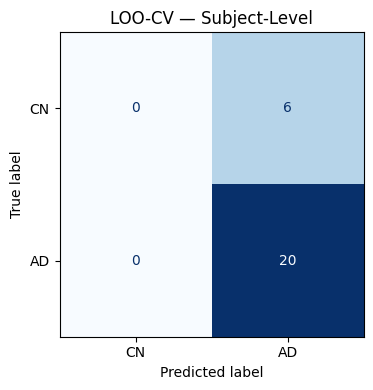

In [11]:
loo_metrics = compute_metrics(loo_true, loo_pred)

print('LOO-CV Results (subject-level, training set only)')
print('=' * 42)
for k, v in loo_metrics.items():
    print(f'  {k:<12}: {v:.3f}')
print('=' * 42)

cm_loo = confusion_matrix(loo_true, loo_pred)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm_loo, display_labels=['CN', 'AD']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('LOO-CV — Subject-Level')
plt.tight_layout()
plt.show()

## 9. Train Final Model on Full Training Set

Uses the same validation set for early stopping.

In [12]:
final_model = XGBClassifier(**XGB_PARAMS)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f'\nBest iteration: {final_model.best_iteration}')

[0]	validation_0-logloss:0.68889
[29]	validation_0-logloss:0.87935

Best iteration: 0


## 10. Evaluate on Held-Out Test Set

Test Results (subject-level)
  Accuracy    : 0.167
  Precision   : 0.167
  Recall      : 1.000
  F1          : 0.286


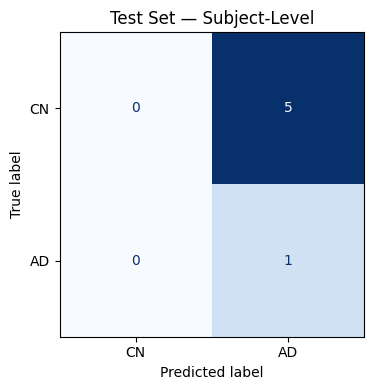

In [13]:
_, test_true, test_pred, _ = aggregate_predictions(final_model, X_test, g_test, y_test)
test_metrics = compute_metrics(test_true, test_pred)

print('Test Results (subject-level)')
print('=' * 42)
for k, v in test_metrics.items():
    print(f'  {k:<12}: {v:.3f}')
print('=' * 42)

cm_test = confusion_matrix(test_true, test_pred)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm_test, display_labels=['CN', 'AD']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Test Set — Subject-Level')
plt.tight_layout()
plt.show()

## 11. Summary — LOO-CV vs Test Metrics


 Final Metrics Summary (Subject-Level)
   Metric LOO-CV Test Set
 Accuracy  0.769    0.167
Precision  0.769    0.167
   Recall  1.000    1.000
       F1  0.870    0.286


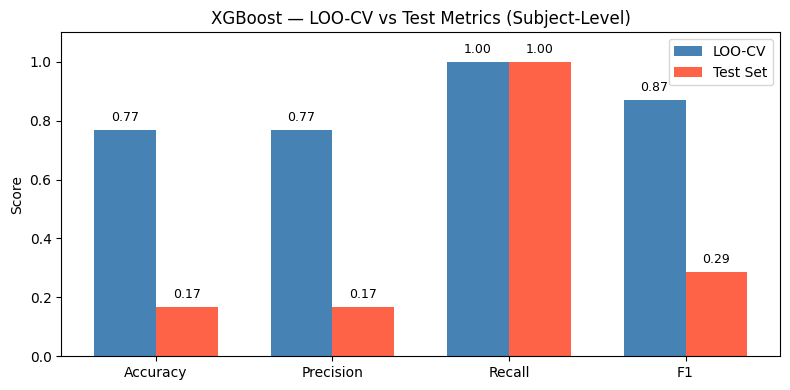

In [14]:
summary = pd.DataFrame({
    'Metric'  : list(loo_metrics.keys()),
    'LOO-CV'  : [f'{v:.3f}' for v in loo_metrics.values()],
    'Test Set': [f'{v:.3f}' for v in test_metrics.values()],
})

print('\n' + '=' * 38)
print(' Final Metrics Summary (Subject-Level)')
print('=' * 38)
print(summary.to_string(index=False))
print('=' * 38)

# Visual bar chart
x = np.arange(len(loo_metrics))
w = 0.35
loo_vals  = list(loo_metrics.values())
test_vals = list(test_metrics.values())

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - w/2, loo_vals,  w, label='LOO-CV',   color='steelblue')
bars2 = ax.bar(x + w/2, test_vals, w, label='Test Set', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(list(loo_metrics.keys()))
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('XGBoost — LOO-CV vs Test Metrics (Subject-Level)')
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()